  <td align="center"><a target="_blank" href="https://colab.research.google.com/drive/1yGH5Mi0GQ8Up0CJFKG8mD_QVidDFBqR3#scrollTo=mx7KZddFUF11">
        <img src="https://i.ibb.co/2P3SLwK/colab.png"  style="padding-bottom:5px;" />Run in Google Colab</a></td>

# Fase 2: Sistema de Detección de EPP (Modelo Robusto Industrial)
**Proyecto de Visión Computacional**

En esta segunda fase del proyecto, evolucionamos nuestro modelo base de detección de Equipo de Protección Personal (EPP). El objetivo principal de esta iteración es **eliminar el sesgo de color** detectado en la Fase 1 (donde el modelo dependía del color amarillo/naranja de los chalecos) y preparar la red neuronal para entornos reales de construcción.

**Mejoras implementadas en la Fase 2:**
* **Escalamiento de Datos:** Pasamos de un dataset base a un volumen masivo de casi 30,000 imágenes mediante técnicas de *Data Augmentation*.
* **Hardware de Alto Rendimiento:** Transición del procesamiento local a un clúster en la nube utilizando una GPU **NVIDIA A100** con High-RAM para acelerar el entrenamiento.
* **Arquitectura:** Entrenamiento desde cero (Transfer Learning) sobre la arquitectura `YOLOv8n` para detectar 11 clases simultáneas de EPP.

In [3]:
# 1. Conectamos tu Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Instalamos librerías y revisamos la GPU
!pip install -q ultralytics roboflow
import torch

if torch.cuda.is_available():
    print(f"¡GPU lista y Drive conectado! Gráfica: {torch.cuda.get_device_name(0)}")
else:
    print("Ojo: No tienes GPU asignada.")

Mounted at /content/drive
¡GPU lista y Drive conectado! Gráfica: NVIDIA A100-SXM4-80GB


## 1. Ingesta de Datos y Data Augmentation
Para simular las condiciones del mundo real (cámaras de seguridad CCTV polvosas, cambios de iluminación por el sol, etc.), conectamos nuestra libreta directamente a Roboflow mediante API para descargar la versión 2 de nuestro dataset.

**Mutaciones aplicadas al vuelo (x3):**
* `Grayscale (15%)` y `Hue (-15° a +15°)`: Obligan al modelo a aprender la **geometría** del casco/chaleco y no su color.
* `Blur (2px)`: Simula el desenfoque y suciedad típica de los lentes en las minas.
* `Flip (Horizontal)`: Duplica la variabilidad de la dirección en la que caminan los trabajadores.

In [4]:
from roboflow import Roboflow

print("Conectando con Roboflow y descargando dataset...")
rf = Roboflow(api_key="i51woqHzaLwjGeEuXLFU")
project = rf.workspace("franciscos-workspace-ukujq").project("ppe10.3-7n1zg")
version = project.version(1)
dataset = version.download("yolov8")
print(f"¡Datos listos en la memoria temporal!")

Conectando con Roboflow y descargando dataset...
loading Roboflow workspace...
loading Roboflow project...
¡Datos listos en la memoria temporal!


## 2. Entrenamiento del Modelo (YOLOv8)
Aprovechando la memoria unificada ampliada y la GPU A100, configuramos un entrenamiento intensivo con los siguientes hiperparámetros:
* **Epochs:** `100` (Con mecanismo de *Early Stopping* de 30 épocas para evitar Overfitting).
* **Batch Size:** `32` (Alimentación masiva de imágenes gracias a la High-RAM).
* **Image Size:** `640px` (Resolución estándar para mantener un balance entre velocidad de inferencia y precisión).

In [5]:
from ultralytics import YOLO
import os

print("Preparando carpeta de seguridad en Google Drive...")
# Creamos una carpeta en TU Drive para guardar todo de forma segura
ruta_drive = '/content/drive/MyDrive/Resultados_EPP_Fase2'
os.makedirs(ruta_drive, exist_ok=True)

print("Cargando modelo YOLOv8n fresco...")
modelo_base = YOLO('yolov8n.pt')

print("Iniciando entrenamiento a prueba de fallos...")
# Ejecutamos el entrenamiento
results = modelo_base.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    patience=30,
    imgsz=640,
    batch=32,
    device=0,
    project=ruta_drive,  # <--- EL BLINDAJE: Guarda directo en tu Drive personal
    name='entrenamiento_seguro'
)

print("¡Entrenamiento completado y respaldado en tu Drive!")

Preparando carpeta de seguridad en Google Drive...
Cargando modelo YOLOv8n fresco...
Iniciando entrenamiento a prueba de fallos...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe10.3-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=

Cargando el modelo recién horneado desde tu Drive...
Buscando en un mar de 1009 fotos...
¡Generando predicciones!



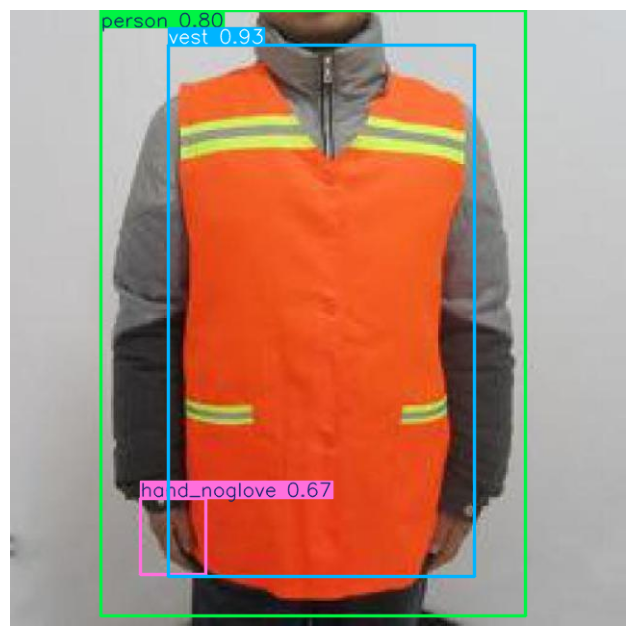

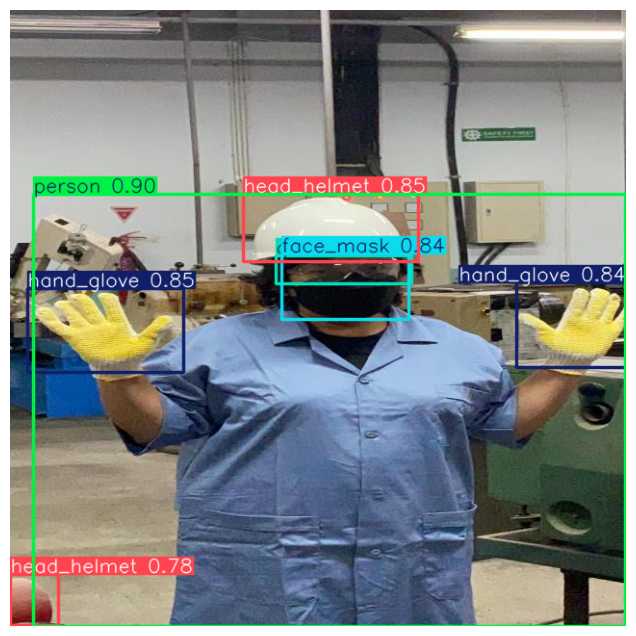

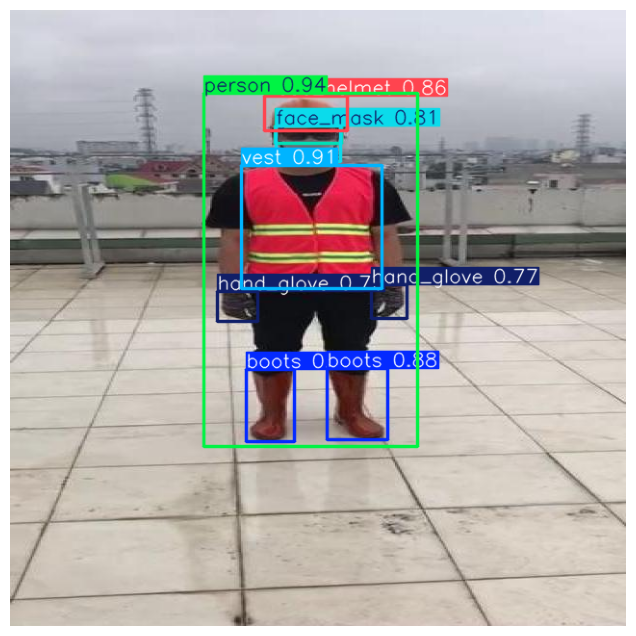

In [ ]:
ßimport glob
import random
import cv2
from matplotlib import pyplot as plt
from ultralytics import YOLO

print("Cargando el modelo recién horneado desde tu Drive...")
modelo_nuevo = YOLO('/content/drive/MyDrive/Resultados_EPP_Fase2/entrenamiento_seguro/weights/best.pt')

# Buscamos todas las imágenes de validación que descargó Roboflow
rutas_imagenes = glob.glob(f"{dataset.location}/valid/images/*.jpg")

# Si no encuentra 'valid', busca en 'test'
if not rutas_imagenes:
    rutas_imagenes = glob.glob(f"{dataset.location}/test/images/*.jpg")

print(f"Buscando en un mar de {len(rutas_imagenes)} fotos...")
# Agarra 3 fotos totalmente al azar
fotos_muestra = random.sample(rutas_imagenes, 3)

print("¡Generando predicciones!\n")
for ruta in fotos_muestra:
    # Hacemos la predicción exigiendo un 50% de seguridad (conf=0.5)
    resultados = modelo_nuevo.predict(source=ruta, conf=0.5, verbose=False)

    # YOLO extrae la imagen ya con las cajas dibujadas
    img_con_cajas = resultados[0].plot()

    # Renderizamos la imagen en la libreta
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img_con_cajas, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()